<a href="https://colab.research.google.com/github/Chase-Troy/Course-Assignments/blob/main/Breast_Cancer_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing required  libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


Load the Dataset

In [2]:
breast_cancer = load_breast_cancer()

x = breast_cancer.data
y = breast_cancer.target

Check sample and target sizes

In [3]:
print(x.shape)
print(y.shape)

(569, 30)
(569,)


Splitting data into training and testing sets

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=11)

print(x_train.shape)
print(x_test.shape)

(426, 30)
(143, 30)


Creating and training the Gaussian Naive Bayes Model

In [5]:
nb = GaussianNB()
nb.fit(x_train, y_train)

GaussianNB()

Code for making predictions

In [6]:
y_pred = nb.predict(x_test)

Evualating the model using score method

In [7]:
accuracy = nb.score(x_test, y_test)
print("Gaussian Accuracy:", accuracy)

Gaussian Accuracy: 0.951048951048951


Confusion Matrix

In [8]:
cm=confusion_matrix(y_test, y_pred)
print("Confussion Matrix:\n",cm)

Confussion Matrix:
 [[44  6]
 [ 1 92]]


Classfication report

In [9]:
print("Classification_report:\n")
print(classification_report(y_test, y_pred, target_names=breast_cancer.target_names))

Classification_report:

              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



Visualizing the Confusion Matrix

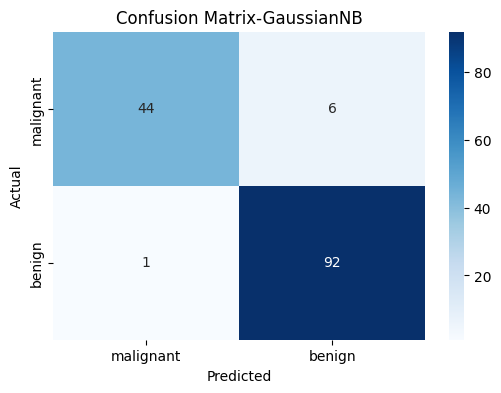

In [10]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=breast_cancer.target_names,
            yticklabels=breast_cancer.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix-GaussianNB")
plt.show()

K- Fold Cross Validation

In [11]:
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

scores = cross_val_score(estimator=nb, X=x, y=y, cv=kfold)

print("Cross-validation scores:\n", scores)
print("Mean accuracy:\n", scores.mean())

Cross-validation scores:
 [0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]
Mean accuracy:
 0.9384711779448622


Comparision of Mutiple Models

In [12]:
estimators = {
    'GaussianNB': GaussianNB(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(solver='lbfgs', max_iter=10000),
    'SVC': SVC(gamma='scale')
}

for name, model in estimators.items():
    scores = cross_val_score(model, x, y, cv=kfold)
    print(f"{name} Average Accuracy: {scores.mean():.4f}")


GaussianNB Average Accuracy: 0.9385
KNeighborsClassifier Average Accuracy: 0.9279
LogisticRegression Average Accuracy: 0.9508
SVC Average Accuracy: 0.9192
